Import the Required Libraries

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

Build Our Quantum Circuit

In [2]:
# Create a circuit with 1 qubit and 1 classical bit for measurement
qc = QuantumCircuit(1, 1)

# Apply Hadamard gate to create equal superposition
qc.h(0)

# Measure the qubit into the classical bit
qc.measure(0, 0)

print(qc.draw())

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


Run Multiple Measurements

In [3]:
# Create simulator
simulator = AerSimulator()

# Run the circuit 1000 times
result = simulator.run(qc, shots=1000).result()
counts = result.get_counts()
print("Measurement results:", counts)

Measurement results: {'0': 501, '1': 499}


Visualise the Results

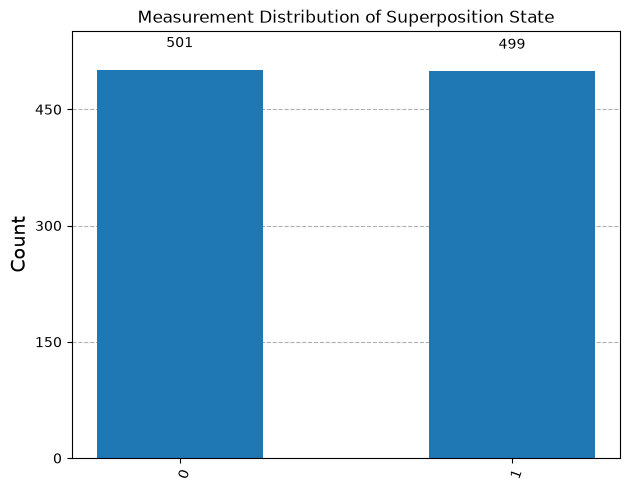

In [4]:
# Create the figure object explicitly
fig = plot_histogram(counts)

# Add title or customization via standard matplotlib syntax
plt.title("Measurement Distribution of Superposition State")

# Display the figure
plt.show()

Run Multiple Trials

In [5]:
# Run 5 separate experiments with 1000 shots each
for trial in range(5):
    result = simulator.run(qc, shots=1000).result()
    counts = result.get_counts()
    zeros = counts.get('0', 0)
    ones = counts.get('1', 0)
    print(f"Trial {trial+1}: 0={zeros}, 1={ones}")

Trial 1: 0=514, 1=486
Trial 2: 0=495, 1=505
Trial 3: 0=516, 1=484
Trial 4: 0=505, 1=495
Trial 5: 0=490, 1=510


Exploring Different Superposition States

Results with RY(π/3): {'1': 241, '0': 759}


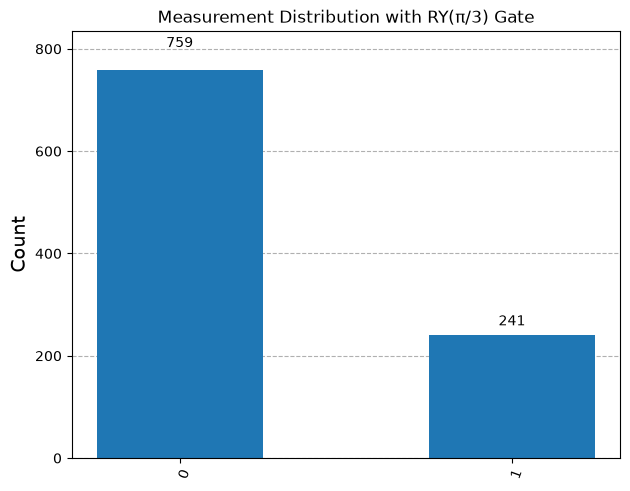

In [6]:
from math import pi

# Create a circuit with rotation gate for adjustable probabilities
qc_rot = QuantumCircuit(1, 1)
qc_rot.ry(pi/3, 0)  # Rotation by 60 degrees
qc_rot.measure(0, 0)

result = simulator.run(qc_rot, shots=1000).result()
counts = result.get_counts()
print("Results with RY(π/3):", counts)
plot_histogram(counts)
plt.title('Measurement Distribution with RY(π/3) Gate')
plt.show()

Final Code

Equal superposition: {'0': 495, '1': 505}


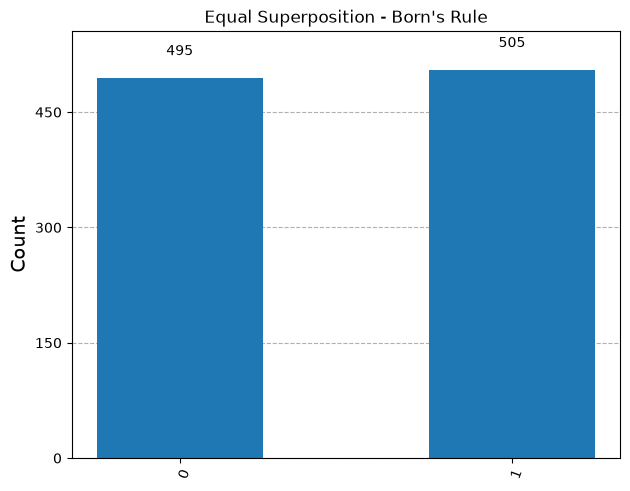

Adjusted superposition: {'1': 263, '0': 737}


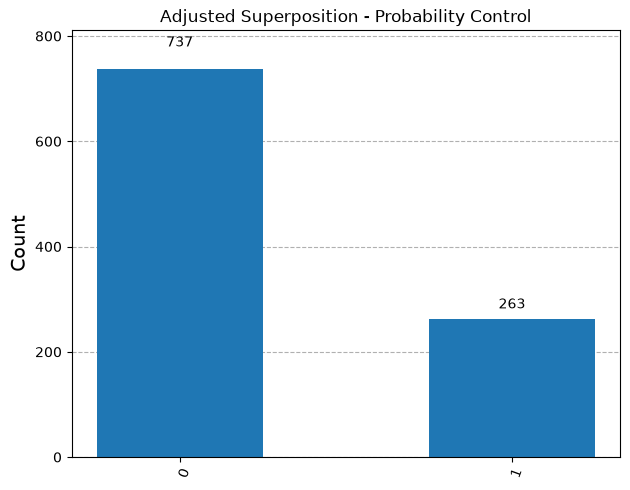

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from math import pi

# Create simulator
simulator = AerSimulator()

# Experiment 1: Equal superposition
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)    
result = simulator.run(qc, shots=1000).result()
counts = result.get_counts()
print("Equal superposition:", counts)
plot_histogram(counts)
plt.title('Equal Superposition - Born\'s Rule')
plt.show()

# Experiment 2: Adjustable superposition
qc_rot = QuantumCircuit(1, 1)
qc_rot.ry(pi/3, 0)
qc_rot.measure(0, 0)
result = simulator.run(qc_rot, shots=1000).result()
counts = result.get_counts()
print("Adjusted superposition:", counts)
plot_histogram(counts)
plt.title('Adjusted Superposition - Probability Control')
plt.show()